In [2]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet
from sklearn.model_selection import train_test_split
import torch

print(f'{torch.cuda.is_available() = }')
print(f'{torch.cuda.device_count() = }')

torch.cuda.is_available() = True
torch.cuda.device_count() = 2


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.8 MB/s eta 0:00:00a 0:00:01


In [4]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.


In [5]:
dataset_path = '/kaggle/input/datasets/andrewmvd/car-plate-detection'

In [6]:
import re

# 'file111.txt' -> 111
def number_in_string(filename):
    match = re.search(r'(\d+)',filename)
    if(match):
        return int(match.group(0))
    else:
        return 0

In [7]:
number_in_string('bca124.txt')

124

In [8]:
labels_dict = dict(
    img_path = [],
    xmin = [],xmax=[],ymin = [],ymax = [],img_w = [],img_h = []
)
labels_dict

{'img_path': [],
 'xmin': [],
 'xmax': [],
 'ymin': [],
 'ymax': [],
 'img_w': [],
 'img_h': []}

In [9]:
import os
from glob import glob
xml_files = glob(f'{dataset_path}/annotations/*.xml')
#xml_files

In [10]:
import xml.etree.ElementTree as xet
import cv2
for filename in sorted(xml_files,key = number_in_string):
    info = xet.parse(filename)
    root = info.getroot()
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)
    img_name = root.find('filename').text
    img_path = os.path.join(dataset_path,'images',img_name)
    height,width,_ = cv2.imread(img_path).shape
    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)
    

In [11]:
alldata = pd.DataFrame(labels_dict)
alldata

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/kaggle/input/datasets/andrewmvd/car-plate-det...,226,419,125,173,500,268
1,/kaggle/input/datasets/andrewmvd/car-plate-det...,134,262,128,160,400,248
2,/kaggle/input/datasets/andrewmvd/car-plate-det...,229,270,176,193,400,400
3,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,261,128,157,400,225
4,/kaggle/input/datasets/andrewmvd/car-plate-det...,156,503,82,253,590,350
...,...,...,...,...,...,...,...
428,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,258,128,157,400,225
429,/kaggle/input/datasets/andrewmvd/car-plate-det...,86,208,166,195,301,400
430,/kaggle/input/datasets/andrewmvd/car-plate-det...,38,116,159,197,400,225
431,/kaggle/input/datasets/andrewmvd/car-plate-det...,55,343,82,147,400,192


In [12]:
from sklearn.model_selection import train_test_split
train_val, test = train_test_split(alldata,test_size = 0.1,random_state=93)
train,val = train_test_split(train_val,train_size = 8/9,random_state=93)

In [13]:
def make_split_folder_in_yolo_format(split_name,split_df):
    labels_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'labels')
    images_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'images')

    os.makedirs(labels_path,exist_ok = True)
    os.makedirs(images_path,exist_ok = True)

    for _,row in split_df.iterrows():
        img_name , img_extension = os.path.splitext(os.path.basename(row['img_path']))
        x_center = ((row['xmin'] + row['xmax']) / 2 )/ row['img_w']
        y_center = ((row['ymin'] + row['ymax']) / 2 )/ row['img_h']
        width = (row['xmax'] - row['xmin']) / row['img_w']
        height = (row['ymax'] - row['ymin']) / row['img_h']
        label_path = os.path.join(labels_path, f'{img_name}.txt')
        with open(label_path, 'w') as file:
            file.write(f"0 {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}\n")
        
        shutil.copy(row['img_path'], os.path.join(images_path, img_name + img_extension))
        
    print(f"Created '{images_path}' and '{labels_path}'")       

In [14]:
make_split_folder_in_yolo_format("train", train)
make_split_folder_in_yolo_format("val", val)
make_split_folder_in_yolo_format("test", test)

Created 'datasets/cars_license_plate_new/train/images' and 'datasets/cars_license_plate_new/train/labels'
Created 'datasets/cars_license_plate_new/val/images' and 'datasets/cars_license_plate_new/val/labels'
Created 'datasets/cars_license_plate_new/test/images' and 'datasets/cars_license_plate_new/test/labels'


In [15]:
# Defining the content of the datasets.yaml file
datasets_yaml = '''
path: cars_license_plate_new

train: train/images
val: val/images
test: test/images

# number of classes
nc: 1

# class names
names: ['license_plate']
'''

# Write the content to the datasets.yaml file
with open('datasets.yaml', 'w') as file:
    file.write(datasets_yaml)

In [16]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [17]:
model = YOLO('yolov8n.pt') # yolo nano 8 model

In [18]:
model.train(
    data = 'datasets.yaml',
    epochs = 100,
    batch = 16,
    device = 'cuda',
    imgsz = 300,
    cache = True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=300, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cbf95586000>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [19]:
log_dir = max(glob('runs/detect/train*'), key=number_in_string)
results = pd.read_csv(os.path.join(log_dir, 'results.csv'))
results

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,4.75291,1.75634,2.94471,1.30160,0.00378,0.90909,0.26963,0.10204,1.32512,2.94262,0.98166,0.000420,0.000420,0.000420
1,2,6.82418,1.58454,1.62975,1.15629,0.03777,0.29545,0.09164,0.03349,1.33347,3.07406,1.09390,0.000851,0.000851,0.000851
2,3,8.83722,1.59106,1.50909,1.18196,0.79867,0.27062,0.36122,0.17021,1.53944,2.75213,1.24476,0.001274,0.001274,0.001274
3,4,10.91060,1.55624,1.36852,1.17960,0.01304,0.25000,0.01137,0.00514,1.75673,3.47431,1.38601,0.001688,0.001688,0.001688
4,5,12.81270,1.66806,1.34484,1.19455,0.56496,0.29545,0.37662,0.15741,1.84185,2.21012,1.33191,0.001921,0.001921,0.001921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,190.62200,0.95447,0.50163,0.98944,0.85924,0.88636,0.89148,0.55158,1.31536,0.58159,1.15024,0.000119,0.000119,0.000119
96,97,192.52000,0.94776,0.49810,0.99324,0.86046,0.88636,0.89003,0.55436,1.28414,0.57759,1.14048,0.000099,0.000099,0.000099
97,98,194.45600,0.93875,0.49237,0.97583,0.84102,0.88636,0.88641,0.55789,1.27743,0.58752,1.14545,0.000079,0.000079,0.000079
98,99,196.32800,0.92896,0.48713,0.98371,0.84398,0.88636,0.88954,0.55198,1.29132,0.58807,1.15068,0.000060,0.000060,0.000060


In [20]:
log_dir = max(glob('runs/detect/train*'), key=number_in_string)
results = pd.read_csv(os.path.join(log_dir, 'results.csv'))
results.columns = results.columns.str.strip()
results

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,4.75291,1.75634,2.94471,1.30160,0.00378,0.90909,0.26963,0.10204,1.32512,2.94262,0.98166,0.000420,0.000420,0.000420
1,2,6.82418,1.58454,1.62975,1.15629,0.03777,0.29545,0.09164,0.03349,1.33347,3.07406,1.09390,0.000851,0.000851,0.000851
2,3,8.83722,1.59106,1.50909,1.18196,0.79867,0.27062,0.36122,0.17021,1.53944,2.75213,1.24476,0.001274,0.001274,0.001274
3,4,10.91060,1.55624,1.36852,1.17960,0.01304,0.25000,0.01137,0.00514,1.75673,3.47431,1.38601,0.001688,0.001688,0.001688
4,5,12.81270,1.66806,1.34484,1.19455,0.56496,0.29545,0.37662,0.15741,1.84185,2.21012,1.33191,0.001921,0.001921,0.001921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,190.62200,0.95447,0.50163,0.98944,0.85924,0.88636,0.89148,0.55158,1.31536,0.58159,1.15024,0.000119,0.000119,0.000119
96,97,192.52000,0.94776,0.49810,0.99324,0.86046,0.88636,0.89003,0.55436,1.28414,0.57759,1.14048,0.000099,0.000099,0.000099
97,98,194.45600,0.93875,0.49237,0.97583,0.84102,0.88636,0.88641,0.55789,1.27743,0.58752,1.14545,0.000079,0.000079,0.000079
98,99,196.32800,0.92896,0.48713,0.98371,0.84398,0.88636,0.88954,0.55198,1.29132,0.58807,1.15068,0.000060,0.000060,0.000060


In [23]:
epochs = results.index+1
results.columns

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

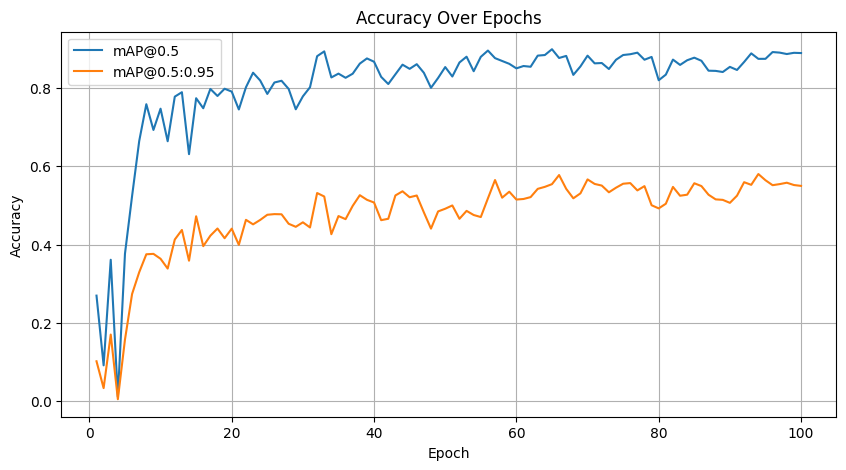

In [25]:
mAP_0_5 = results['metrics/mAP50(B)']
mAP_0_5_0_95 = results['metrics/mAP50-95(B)']
plt.figure(figsize=(10, 5))
plt.plot(epochs, mAP_0_5, label='mAP@0.5')
plt.plot(epochs, mAP_0_5_0_95, label='mAP@0.5:0.95')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model.save('best_license_plate_model.pt')

In [27]:
def predict_and_plot(path_test_car):
    results = model.predict(path_test_car, device='cpu')
    image = cv2.imread(path_test_car)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0]

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, f'{confidence*100:.2f}%', (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
            
    plt.imshow(image)
    plt.axis('off')  
    plt.show()  


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars274.png: 256x320 2 license_plates, 57.8ms
Speed: 0.9ms preprocess, 57.8ms inference, 23.0ms postprocess per image at shape (1, 3, 256, 320)


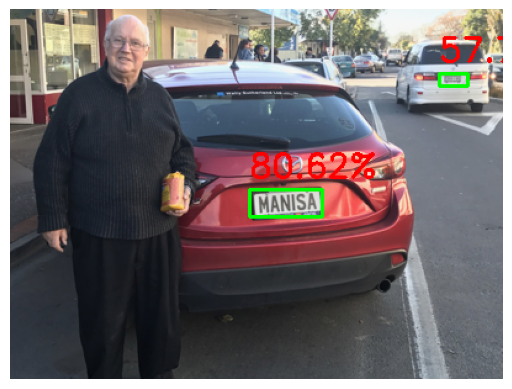

In [28]:
predict_and_plot(test.iloc[0].img_path)


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars328.png: 192x320 1 license_plate, 45.4ms
Speed: 0.9ms preprocess, 45.4ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 320)


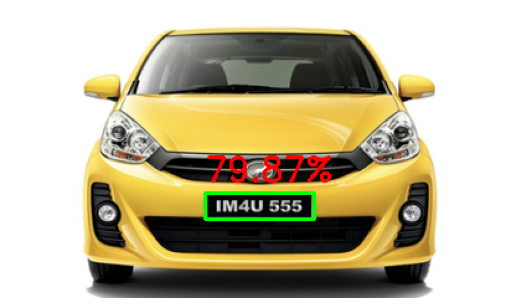

In [29]:
predict_and_plot(test.iloc[7].img_path)


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars211.png: 256x320 2 license_plates, 27.3ms
Speed: 1.0ms preprocess, 27.3ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 320)


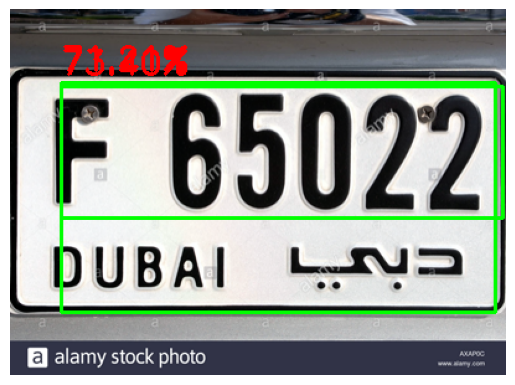

In [30]:
predict_and_plot(test.iloc[3].img_path)

In [31]:
!pip install easyocr

In [32]:
import easyocr

In [33]:
reader = easyocr.Reader(['en'], gpu=True)

def predict_and_plot(path_test_car):
    results = model.predict(path_test_car, device='cpu')
    image = cv2.imread(path_test_car)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0]

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

            cv2.putText(image, f'{confidence*100:.2f}%', (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

            roi = image[y1:y2, x1:x2]

            ocr_results = reader.readtext(roi)
            
            text = " ".join([detection[1] for detection in ocr_results])
            print(f"Detected text: {text}")

    plt.imshow(image)
    plt.axis('off')  
    plt.show()  


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars274.png: 256x320 2 license_plates, 30.9ms
Speed: 1.2ms preprocess, 30.9ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 320)
Detected text: [MANIS
Detected text: 


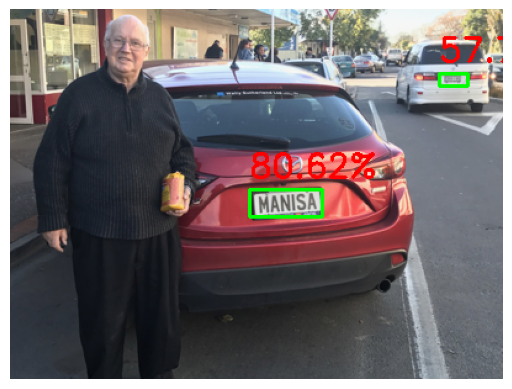

In [34]:
predict_and_plot(test.iloc[0].img_path)


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars328.png: 192x320 1 license_plate, 24.7ms
Speed: 0.8ms preprocess, 24.7ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 320)
Detected text: IMAU 555


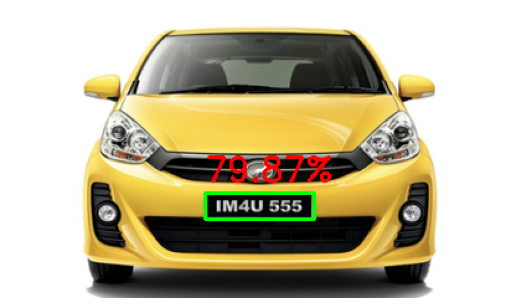

In [35]:
predict_and_plot(test.iloc[7].img_path)


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars419.png: 288x320 1 license_plate, 56.2ms
Speed: 1.0ms preprocess, 56.2ms inference, 0.7ms postprocess per image at shape (1, 3, 288, 320)
Detected text: MHIL Gn 9239


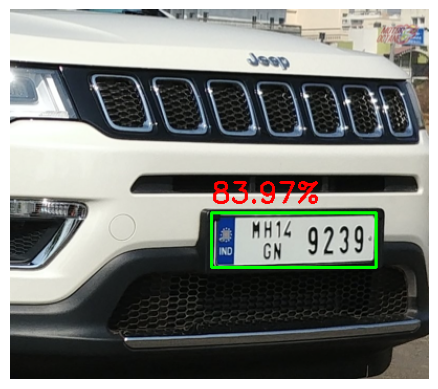

In [36]:
predict_and_plot(test.iloc[5].img_path)